# Ejercicio 6. Topología y fragmentación

Las tres redes del ejercicio anterior se miden aquí con el mismo juego de
métricas para poder compararlas: tamaño, densidad, grado medio, distribución
de grados, componentes conexos, cohesión y transitividad. Después se
identifica lo periférico y lo aislado, y se separa con cuidado el aislamiento
que los datos muestran del que los datos simplemente no pueden ver.

Dos advertencias metodológicas que atraviesan todo el cuaderno:

1. **La densidad de una red bipartita no se calcula con la fórmula normal.**
   En una red de un modo el máximo de aristas es *n(n−1)/2*; en una bipartita
   es el producto de los tamaños de los dos conjuntos, porque un autor nunca
   puede conectarse con otro autor. Usar la fórmula equivocada aquí divide la
   densidad por casi diez.
2. **Las métricas de la proyección autor-autor están infladas por
   construcción**, según se mostró en el ejercicio 5. Se reportan porque el
   enunciado las pide, y se acompañan siempre de la lectura correcta.

In [1]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms import bipartite as bp

from src import config, datos, redes

warnings.filterwarnings("ignore")
config.preparar_directorios()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

videos = datos.cargar_videos()
comentarios = datos.cargar_comentarios()

B = redes.construir_bipartita(comentarios, videos)
PA = redes.proyeccion_autores(B)
PV = redes.proyeccion_videos(B)

nodos_autor = redes.nodos_por_tipo(B, redes.AUTOR)
nodos_video = redes.nodos_por_tipo(B, redes.VIDEO)

print(f"Bipartita       : {B.number_of_nodes():>6,} nodos  {B.number_of_edges():>7,} aristas")
print(f"Autor-autor     : {PA.number_of_nodes():>6,} nodos  {PA.number_of_edges():>7,} aristas")
print(f"Video-video     : {PV.number_of_nodes():>6,} nodos  {PV.number_of_edges():>7,} aristas")

Bipartita       :    351 nodos      343 aristas
Autor-autor     :    332 nodos   10,732 aristas
Video-video     :     19 nodos       11 aristas


## 6.1 Nodos, aristas, densidad, grado y componentes

In [2]:
metricas = pd.DataFrame(
    {
        "Bipartita autor-video": redes.resumen(B, bipartita=True),
        "Proyeccion autor-autor": redes.resumen(PA),
        "Proyeccion video-video": redes.resumen(PV),
    }
).T

metricas["densidad_mal_calculada"] = [nx.density(B), np.nan, np.nan]
presentacion = metricas[
    ["nodos", "aristas", "densidad", "grado_medio", "grado_max",
     "componentes", "componente_mayor", "componente_mayor_prop", "aislados"]
].copy()
presentacion["densidad"] = presentacion["densidad"].round(4)
presentacion["grado_medio"] = presentacion["grado_medio"].round(2)
presentacion["componente_mayor_prop"] = (presentacion["componente_mayor_prop"] * 100).round(1)
presentacion = presentacion.rename(columns={"componente_mayor_prop": "comp_mayor_%"})
print(presentacion.to_string())

print(
    f"\nDensidad bipartita con la formula correcta : {nx.bipartite.density(B, nodos_autor):.4f}"
    f"\nDensidad bipartita con la formula de un modo: {nx.density(B):.4f}"
    f"\n  (la segunda subestima la densidad {nx.bipartite.density(B, nodos_autor) / nx.density(B):.1f} veces)"
)

                        nodos  aristas  densidad  grado_medio  grado_max  componentes  componente_mayor  comp_mayor_%  aislados
Bipartita autor-video   351.0    343.0    0.0544         1.95      128.0         10.0             286.0          81.5       0.0
Proyeccion autor-autor  332.0  10732.0    0.1953        64.65      183.0         10.0             276.0          83.1       4.0
Proyeccion video-video   19.0     11.0    0.0643         1.16        4.0         10.0              10.0          52.6       9.0

Densidad bipartita con la formula correcta : 0.0544
Densidad bipartita con la formula de un modo: 0.0056
  (la segunda subestima la densidad 9.7 veces)


### Distribución de grados

En la bipartita hay que separar los dos lados. Mezclarlos no tiene sentido:
el grado de un autor es *en cuántos videos comentó* y el grado de un video es
*cuántas personas distintas lo comentaron*. Son dos poblaciones con escalas
incomparables, una entre 1 y 3 y la otra entre 1 y 128.

In [3]:
grados_autor = pd.Series([B.degree(n) for n in nodos_autor])
grados_video = pd.Series([B.degree(n) for n in nodos_video])
pesos_autor = pd.Series([B.degree(n, weight="weight") for n in nodos_autor])

print("--- Lado de los autores (grado = videos distintos comentados) ---")
print(grados_autor.value_counts().sort_index().rename("autores").to_string())
print(f"\n  media {grados_autor.mean():.3f}   mediana {grados_autor.median():.0f}   maximo {grados_autor.max()}")
print(f"  autores con grado 1: {(grados_autor == 1).sum()} ({(grados_autor == 1).mean():.1%})")

print("\n--- Lado de los videos (grado = autores distintos) ---")
print(grados_video.sort_values(ascending=False).to_string(index=False))
print(f"\n  media {grados_video.mean():.2f}   mediana {grados_video.median():.0f}   maximo {grados_video.max()}")

print("\n--- Comentarios por autor (grado ponderado) ---")
print(pesos_autor.value_counts().sort_index().rename("autores").to_string())

--- Lado de los autores (grado = videos distintos comentados) ---
1    323
2      7
3      2

  media 1.033   mediana 1   maximo 3
  autores con grado 1: 323 (97.3%)

--- Lado de los videos (grado = autores distintos) ---
128
 49
 32
 25
 19
 18
 16
 13
 10
  7
  7
  6
  4
  3
  2
  1
  1
  1
  1

  media 18.05   mediana 7   maximo 128

--- Comentarios por autor (grado ponderado) ---
1    286
2     30
3     10
4      2
5      2
6      2


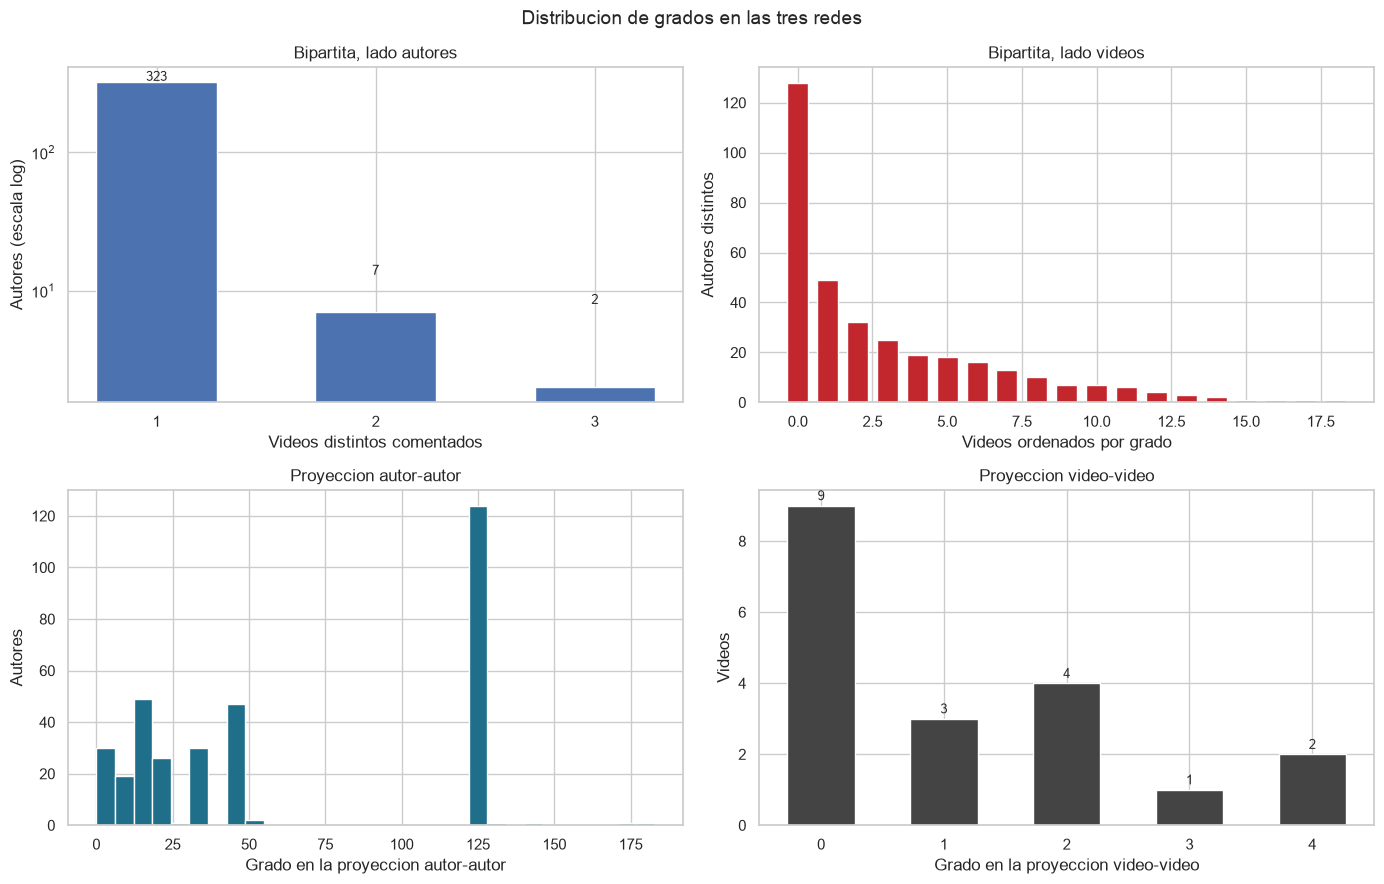

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
conteo = grados_autor.value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color=config.COLORES["autor"], width=0.55)
for x, y in zip(conteo.index, conteo.values):
    ax.text(x, y + 6, f"{y}", ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_xticks([1, 2, 3])
ax.set_xlabel("Videos distintos comentados")
ax.set_ylabel("Autores (escala log)")
ax.set_title("Bipartita, lado autores")

ax = axes[0, 1]
orden = grados_video.sort_values(ascending=False).reset_index(drop=True)
ax.bar(range(len(orden)), orden.values, color=config.COLORES["video"], width=0.7)
ax.set_xlabel("Videos ordenados por grado")
ax.set_ylabel("Autores distintos")
ax.set_title("Bipartita, lado videos")

ax = axes[1, 0]
grados_pa = pd.Series([d for _, d in PA.degree()])
ax.hist(grados_pa, bins=30, color=config.COLORES["acento"], edgecolor="white")
ax.set_xlabel("Grado en la proyeccion autor-autor")
ax.set_ylabel("Autores")
ax.set_title("Proyeccion autor-autor")

ax = axes[1, 1]
grados_pv = pd.Series([d for _, d in PV.degree()])
conteo_pv = grados_pv.value_counts().sort_index()
ax.bar(conteo_pv.index, conteo_pv.values, color=config.COLORES["gris"], width=0.55)
for x, y in zip(conteo_pv.index, conteo_pv.values):
    ax.text(x, y + 0.15, f"{y}", ha="center", fontsize=9)
ax.set_xlabel("Grado en la proyeccion video-video")
ax.set_ylabel("Videos")
ax.set_title("Proyeccion video-video")

fig.suptitle("Distribucion de grados en las tres redes", fontsize=14)
plt.tight_layout()
plt.savefig(config.FIGURAS / "06_distribucion_grados.png", dpi=150, bbox_inches="tight")
plt.show()

**La respuesta a la pregunta del enunciado es inequívoca: la mayoría tiene
muy pocas conexiones y unos pocos concentran casi todo.**

En el lado de los autores, 323 de 332 (97.3 %) tienen grado 1: comentaron en
un solo video y no aparecen en ningún otro. Sólo 9 tienen grado 2 o 3.

En el lado de los videos la asimetría es aún mayor. El grado va de 1 a 128,
y el video más comentado concentra más autores que los quince videos menos
comentados juntos. No es una distribución con cola pesada en sentido
estadístico —con 19 puntos no se puede afirmar eso—, pero sí es una
concentración extrema perfectamente visible.

La proyección autor-autor tiene grados enormes (media 64.7) por la razón ya
explicada: el grado de un autor ahí es esencialmente *cuánta gente comentó en
el mismo video que él*, no cuánta gente conoce.

### Componentes conexos

Las tres redes tienen exactamente **10 componentes**, y no es coincidencia:
la conectividad de las tres la determinan los mismos nueve autores puente.

In [5]:
filas = []
for comp in sorted(nx.connected_components(B), key=len, reverse=True):
    vids = [n for n in comp if B.nodes[n]["tipo"] == redes.VIDEO]
    auts = [n for n in comp if B.nodes[n]["tipo"] == redes.AUTOR]
    filas.append(
        {
            "nodos": len(comp),
            "autores": len(auts),
            "videos": len(vids),
            "comentarios": sum(d["weight"] for _, _, d in B.subgraph(comp).edges(data=True)),
            "canales": len({B.nodes[n].get("canal", "") for n in vids}),
            "titulo_representativo": max(
                vids, key=lambda n: B.degree(n, weight="weight")
            ),
        }
    )

tabla_comp = pd.DataFrame(filas)
tabla_comp["titulo_representativo"] = tabla_comp["titulo_representativo"].map(
    lambda n: B.nodes[n]["etiqueta"][:44]
)
tabla_comp.index = [f"C{i + 1}" for i in range(len(tabla_comp))]
print(tabla_comp.to_string())

print(
    f"\nLa componente mayor tiene {tabla_comp.iloc[0]['nodos']} de {B.number_of_nodes()} nodos "
    f"({tabla_comp.iloc[0]['nodos'] / B.number_of_nodes():.1%}) y "
    f"{tabla_comp.iloc[0]['comentarios']} de {len(comentarios)} comentarios "
    f"({tabla_comp.iloc[0]['comentarios'] / len(comentarios):.1%})."
)
print(f"Las otras nueve componentes son un video con su publico y nada mas.")

     nodos  autores  videos  comentarios  canales                         titulo_representativo
C1     286      276      10          343        5                     Qué rico come tu diputado
C2      26       25       1           25        1                 Plan 2032 Ciudad de Guatemala
C3      19       18       1           25        1  EE.UU. envía a mexicanos deportados a Guatem
C4       5        4       1            4        1  I’x K’at: el primer equipo guatemalteco de p
C5       4        3       1            3        1       10 Preguntas a un año del Paro Nacional
C6       3        2       1            2        1  Noticiero en Directo 1 pm, 28 de Agosto de 2
C7       2        1       1            1        1          Cruzando la ciudad a puro Transmetro
C8       2        1       1            1        1  Edén por Salud: empleo inclusivo para person
C9       2        1       1            1        1  SHAI WA: la vecina queer de Casa Presidencia
C10      2        1       1            1

## 6.2 Cohesión y transitividad

In [6]:
comp_pa = redes.componente_mayor(PA)
comp_pv = redes.componente_mayor(PV)

cohesion = pd.DataFrame(
    [
        {
            "red": "Bipartita autor-video",
            "densidad": nx.bipartite.density(B, nodos_autor),
            "transitividad": nx.transitivity(B),
            "agrupamiento_medio": nx.average_clustering(B),
            "agrupamiento_bipartito": np.mean(list(bp.clustering(B, mode="dot").values())),
            "conectividad_nodos": nx.node_connectivity(redes.componente_mayor(B)),
            "conectividad_aristas": nx.edge_connectivity(redes.componente_mayor(B)),
            "diametro_comp_mayor": nx.diameter(redes.componente_mayor(B)),
        },
        {
            "red": "Proyeccion autor-autor",
            "densidad": nx.density(PA),
            "transitividad": nx.transitivity(PA),
            "agrupamiento_medio": nx.average_clustering(PA),
            "agrupamiento_bipartito": np.nan,
            "conectividad_nodos": nx.node_connectivity(comp_pa),
            "conectividad_aristas": nx.edge_connectivity(comp_pa),
            "diametro_comp_mayor": nx.diameter(comp_pa),
        },
        {
            "red": "Proyeccion video-video",
            "densidad": nx.density(PV),
            "transitividad": nx.transitivity(PV),
            "agrupamiento_medio": nx.average_clustering(PV),
            "agrupamiento_bipartito": np.nan,
            "conectividad_nodos": nx.node_connectivity(comp_pv),
            "conectividad_aristas": nx.edge_connectivity(comp_pv),
            "diametro_comp_mayor": nx.diameter(comp_pv),
        },
    ]
).set_index("red")

print(cohesion.round(4).to_string())

                        densidad  transitividad  agrupamiento_medio  agrupamiento_bipartito  conectividad_nodos  conectividad_aristas  diametro_comp_mayor
red                                                                                                                                                       
Bipartita autor-video     0.0544         0.0000              0.0000                   0.892                   1                     1                   12
Proyeccion autor-autor    0.1953         0.9840              0.9720                     NaN                   1                     5                    6
Proyeccion video-video    0.0643         0.3158              0.1491                     NaN                   1                     1                    5


### Por qué la transitividad de la bipartita es exactamente cero

No es un error de cálculo ni una red rara: **una red bipartita no puede tener
triángulos**. Un triángulo necesita tres nodos conectados entre sí, y en una
bipartita toda arista cruza de un lado al otro, así que cualquier ciclo tiene
longitud par. Reportar «transitividad 0» sin decir esto sugeriría que no hay
cohesión, cuando lo que ocurre es que la métrica no aplica.

La alternativa correcta es el **coeficiente de agrupamiento bipartito** de
Latapy, que mide superposición de vecindarios en lugar de triángulos: dos
autores «se agrupan» si comentaron en los mismos videos. Su valor es 0.892,
alto, y significa que los vecindarios se superponen muchísimo — otra forma de
decir que casi todo el mundo está dentro de un solo video.

### Cohesión: la componente mayor se corta con un solo nodo

La conectividad de nodos de la componente mayor es **1** en las tres redes.
Existe al menos un nodo cuya eliminación parte la componente en dos. En una
red de 286 nodos y 331 aristas eso es fragilidad estructural máxima: no hay
rutas redundantes. La identificación concreta de esos nodos de corte es el
ejercicio 8.3, que la aborda con las medidas de centralidad.

El diámetro de la componente mayor de la bipartita es 12: para ir de un autor
al más lejano hay que atravesar seis videos encadenados. En la proyección
video-video el diámetro es 5 sobre sólo 10 nodos, lo que confirma que ese
componente es una cadena larga y delgada, no un núcleo compacto.

## 6.3 Periferia, aislamiento y ausencia de datos

Esta es la parte donde es más fácil equivocarse al interpretar, y el
enunciado lo advierte de forma explícita. Hay tres situaciones distintas que
se parecen entre sí en un grafo y no significan lo mismo.

In [7]:
videos_sin_comentarios = set(videos["video_id"]) - set(comentarios["video_id"])
aislados_pv = [n for n in PV.nodes() if PV.degree(n) == 0]
aislados_pa = [n for n in PA.nodes() if PA.degree(n) == 0]

situaciones = pd.DataFrame(
    [
        {
            "situacion": "1. Aislamiento observado (video)",
            "casos": len(aislados_pv),
            "que_significa": "Tiene comentarios, pero ninguno de sus autores comento otro video de la muestra",
        },
        {
            "situacion": "2. Aislamiento observado (autor)",
            "casos": len(aislados_pa),
            "que_significa": "Unico comentarista de su video: no coincide con nadie ni siquiera ahi",
        },
        {
            "situacion": "3. Ausencia de datos (video)",
            "casos": len(videos_sin_comentarios),
            "que_significa": "No se recolectaron comentarios suyos. No esta en la red en absoluto",
        },
        {
            "situacion": "4. Periferia (autor de grado 1)",
            "casos": int((grados_autor == 1).sum()),
            "que_significa": "Comento en un solo video. Esta en la red pero no la conecta",
        },
    ]
)
print(situaciones.to_string(index=False))

print(f"\nDe los {len(videos)} videos del conjunto:")
print(f"  {comentarios['video_id'].nunique():>4} tienen comentarios y forman la red")
print(f"  {len(videos_sin_comentarios):>4} no tienen ninguno y quedan fuera ({len(videos_sin_comentarios) / len(videos):.1%})")

                       situacion  casos                                                                   que_significa
1. Aislamiento observado (video)      9 Tiene comentarios, pero ninguno de sus autores comento otro video de la muestra
2. Aislamiento observado (autor)      4           Unico comentarista de su video: no coincide con nadie ni siquiera ahi
    3. Ausencia de datos (video)    274             No se recolectaron comentarios suyos. No esta en la red en absoluto
 4. Periferia (autor de grado 1)    323                     Comento en un solo video. Esta en la red pero no la conecta

De los 293 videos del conjunto:
    19 tienen comentarios y forman la red
   274 no tienen ninguno y quedan fuera (93.5%)


**La distinción que importa.** Los 274 videos sin comentarios *no son videos
aislados*. Son videos sobre los que no hay información. No aparecen en
ninguna figura ni en ninguna métrica de red de este laboratorio, y sería un
error grave concluir que «no generan participación»: lo único que se sabe es
que la recolección no trajo sus comentarios. El propio conjunto lo insinúa —
hay videos con 8.1 millones de vistas y cero comentarios recolectados, lo que
no es plausible como comportamiento real de la audiencia.

In [8]:
sin_comentarios = videos[videos["video_id"].isin(videos_sin_comentarios)]
print("Los videos mas vistos que quedaron fuera de la red por falta de comentarios:")
print(
    sin_comentarios.nlargest(8, "vistas")[["title", "channel_name", "vistas", "category"]]
    .assign(title=lambda d: d["title"].str.slice(0, 46))
    .to_string(index=False)
)

con_comentarios = videos[videos["video_id"].isin(set(comentarios["video_id"]))]
print(
    f"\nVistas medianas de los videos en la red      : {con_comentarios['vistas'].median():>12,.0f}"
    f"\nVistas medianas de los videos fuera de la red: {sin_comentarios['vistas'].median():>12,.0f}"
)

Los videos mas vistos que quedaron fuera de la red por falta de comentarios:
                                         title           channel_name    vistas        category
Los ALUCINANTES autobuses de Guatemala | "Burr       Luisito Comunica 8190449.0          Comedy
🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS D             De todo Gt 3152619.0  People & Blogs
🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El M       El Mapa de Sebas  749356.0       Education
   Este BUS me LLEVO a UN PARAISO EN GUATEMALA             De todo Gt  504374.0  People & Blogs
 ✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA             De todo Gt  424874.0 Travel & Events
Sonido de trafico y ciudad 💤 ruido de calle pa Ambient Sound Explorer  330057.0   Entertainment
ME quité el MIEDO de viajar en los buses de GU             De todo Gt  329489.0  People & Blogs
        Tercer Informe General de la República  Gobierno de Guatemala  305269.0 News & Politics

Vistas medianas de los videos en la red      :        1,95

In [9]:
print("Los 4 autores aislados incluso dentro de su propio video:")
for n in aislados_pa:
    original = PA.nodes[n]["id_original"]
    fila = comentarios[comentarios["author_channel_id"] == original].iloc[0]
    print(f"  {PA.nodes[n]['etiqueta']:<34} unico comentarista de: {fila['video_title'][:44]}")

print("\nGrado y peso de la periferia frente al nucleo:")
periferia = pd.DataFrame(
    {
        "grupo": ["Autores de grado 1", "Autores puente (grado > 1)"],
        "autores": [int((grados_autor == 1).sum()), int((grados_autor > 1).sum())],
        "comentarios": [
            int(pesos_autor[grados_autor.values == 1].sum()),
            int(pesos_autor[grados_autor.values > 1].sum()),
        ],
    }
)
periferia["% autores"] = (periferia["autores"] / periferia["autores"].sum() * 100).round(1)
periferia["% comentarios"] = (periferia["comentarios"] / periferia["comentarios"].sum() * 100).round(1)
print(periferia.to_string(index=False))

Los 4 autores aislados incluso dentro de su propio video:
  @elizabethmonterroso7719           unico comentarista de: Cruzando la ciudad a puro Transmetro
  @elioelias7267                     unico comentarista de: Edén por Salud: empleo inclusivo para person
  @aditalissethevasquezrojas8039     unico comentarista de: SHAI WA: la vecina queer de Casa Presidencia
  @jahirdiaz5862                     unico comentarista de: ¿Quiénes pagan más en Centroamérica?

Grado y peso de la periferia frente al nucleo:
                     grupo  autores  comentarios  % autores  % comentarios
        Autores de grado 1      323          383       97.3           94.3
Autores puente (grado > 1)        9           23        2.7            5.7


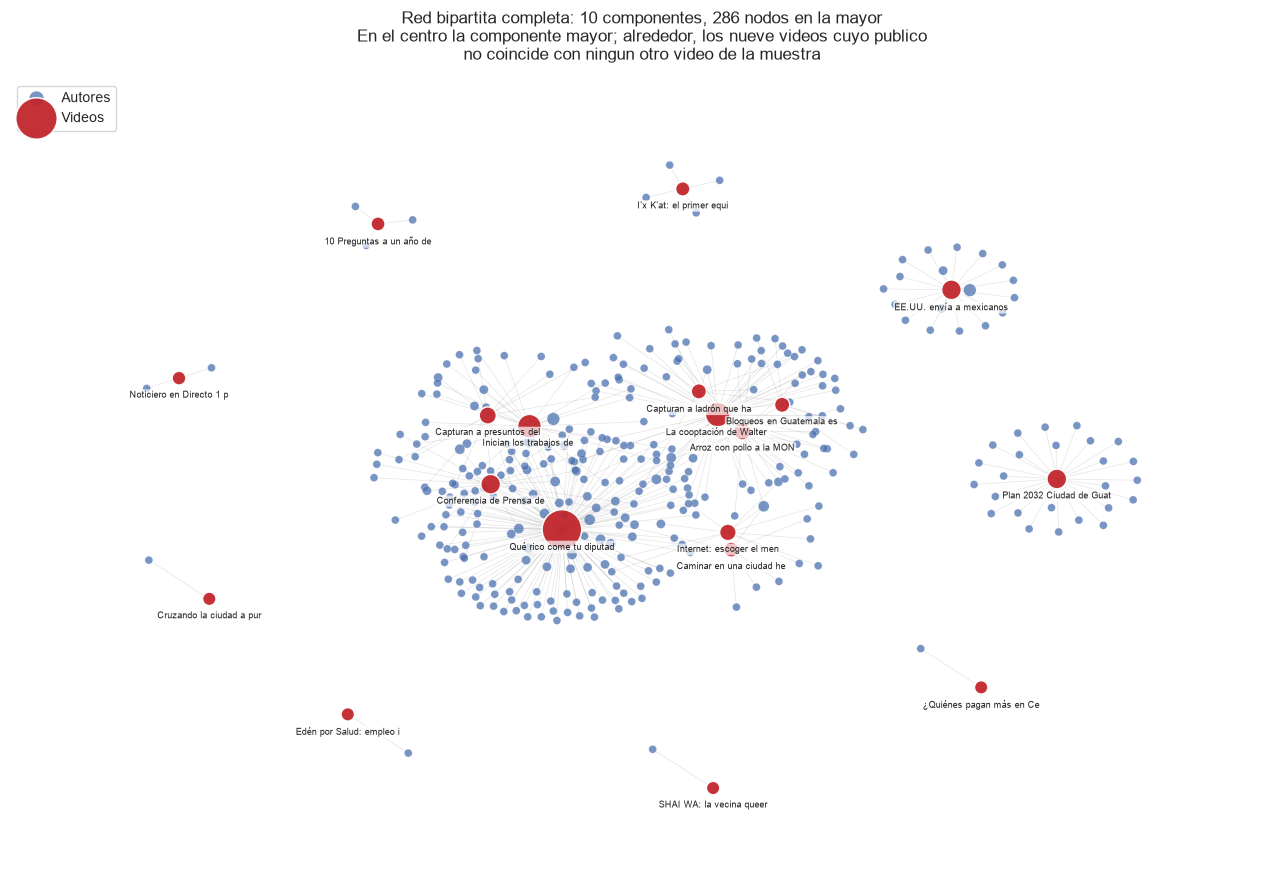

In [10]:
fig, ax = plt.subplots(figsize=(13, 9))

# La disposicion de resortes de networkx no separa las componentes: las
# amontona en el mismo espacio y la figura sugiere una conectividad que no
# existe. Se dispone cada componente por separado y luego se colocan las
# pequenas en un anillo alrededor de la mayor, que es lo que hace visible el
# hallazgo estructural.
componentes = sorted(nx.connected_components(B), key=len, reverse=True)
pos = {}
principal = B.subgraph(componentes[0])
pos.update(nx.spring_layout(principal, seed=config.SEMILLA, k=0.30, scale=1.0))

sueltas = componentes[1:]
for i, comp in enumerate(sueltas):
    angulo = 2 * np.pi * i / len(sueltas)
    centro = np.array([1.75 * np.cos(angulo), 1.75 * np.sin(angulo)])
    sub = B.subgraph(comp)
    escala = 0.10 + 0.22 * (len(comp) / len(componentes[1]))
    local = nx.spring_layout(sub, seed=config.SEMILLA, scale=escala)
    for nodo, coord in local.items():
        pos[nodo] = coord + centro
tam_autor = [22 + 10 * B.degree(n, weight="weight") for n in nodos_autor]
tam_video = [90 + 4.5 * B.degree(n, weight="weight") for n in nodos_video]

nx.draw_networkx_edges(B, pos, alpha=0.22, width=0.5, edge_color="#888888", ax=ax)
nx.draw_networkx_nodes(
    B, pos, nodelist=nodos_autor, node_size=tam_autor,
    node_color=config.COLORES["autor"], alpha=0.75,
    linewidths=0.2, edgecolors="white", label="Autores", ax=ax,
)
nx.draw_networkx_nodes(
    B, pos, nodelist=nodos_video, node_size=tam_video,
    node_color=config.COLORES["video"], alpha=0.95,
    linewidths=1.1, edgecolors="white", label="Videos", ax=ax,
)
for n in nodos_video:
    x, y = pos[n]
    ax.annotate(
        B.nodes[n]["etiqueta"][:24], (x, y), fontsize=6.5, ha="center", va="top",
        xytext=(0, -9), textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="none", alpha=0.7),
    )

ax.legend(loc="upper left", fontsize=10, markerscale=1.4, frameon=True)
ax.set_title(
    "Red bipartita completa: 10 componentes, 286 nodos en la mayor\n"
    "En el centro la componente mayor; alrededor, los nueve videos cuyo publico\n"
    "no coincide con ningun otro video de la muestra",
    fontsize=12, pad=14,
)
ax.axis("off")
ax.margins(0.08)
plt.tight_layout()
plt.savefig(config.FIGURAS / "06_bipartita_componentes.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.4 Qué dicen los análisis estructurales

**1. La red no es una red social, es un conjunto de audiencias.** El dato que
lo resume todo: 97.3 % de los autores tiene grado 1. La estructura observada
es la de un público que llega a un contenido, comenta y no vuelve a aparecer.
No hay comunidad de usuarios que se siga entre videos; hay públicos que
coinciden en un lugar.

**2. La conectividad depende de nueve personas.** Las tres redes tienen 10
componentes y las tres tienen conectividad de nodos igual a 1. Los nueve
autores que comentaron en más de un video son literalmente lo único que
impide que la red sean 19 islas. Quitar a uno solo de ellos parte la
componente mayor, que con 286 nodos tiene apenas 287 aristas: casi un árbol,
sin rutas alternativas. Esto es fragilidad, no cohesión, y conviene no
confundirla
con la densidad alta de la proyección autor-autor, que es un artefacto.

**3. La componente mayor no es un núcleo temático, es un efecto de un canal.**
Los 286 nodos de la componente mayor incluyen 10 videos, de los cuales 5 son
de Quorum. Ese canal aporta 11 de los 19 videos con comentarios y 256 de los
406 comentarios. Buena parte de lo que parece «estructura de la conversación
guatemalteca» es en realidad la estructura del muestreo: se consultó ese canal
de forma dirigida y por eso domina.

**4. La concentración es extrema en los dos lados.** Un solo video, «Qué rico
come tu diputado», reúne 161 de los 406 comentarios (39.7 %) y 128 de los 332
autores (38.6 %). Cualquier promedio calculado sobre los 19 videos está
descrito por ese único caso y hay que reportarlo con la mediana al lado.

**5. Casi toda la muestra de videos no participa en la red.** 274 de 293
videos (93.5 %) no tienen comentarios recolectados. La red que se analiza en
los ejercicios 5 a 8 describe al 6.5 % del conjunto de videos, y ese 6.5 % no
fue elegido al azar. Es la limitación más seria del laboratorio y vuelve a
aparecer en el ejercicio 10.

In [11]:
video_top = comentarios["video_id"].value_counts().index[0]
n_top = redes.clave_video(video_top)
print(f"Video dominante: {B.nodes[n_top]['etiqueta']}")
print(f"  comentarios : {B.degree(n_top, weight='weight')} de {len(comentarios)} ({B.degree(n_top, weight='weight') / len(comentarios):.1%})")
print(f"  autores     : {B.degree(n_top)} de {len(nodos_autor)} ({B.degree(n_top) / len(nodos_autor):.1%})")

por_canal = comentarios.groupby("channel_name").agg(
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    autores=("author_channel_id", "nunique"),
).sort_values("comentarios", ascending=False)
por_canal["% comentarios"] = (por_canal["comentarios"] / len(comentarios) * 100).round(1)
print("\nParticipacion por canal en la red:")
print(por_canal.to_string())

Video dominante: Qué rico come tu diputado
  comentarios : 161 de 406 (39.7%)
  autores     : 128 de 332 (38.6%)

Participacion por canal en la red:
                                       comentarios  videos  autores  % comentarios
channel_name                                                                      
Quorum                                         256      11      214           63.1
Gobierno de la República de Guatemala           70       2       50           17.2
Municipalidad de Guatemala                      25       1       25            6.2
Noticias Telemundo                              25       1       18            6.2
Noti7                                           14       1       13            3.4
PrensaLibreOficial                               7       1        7            1.7
TN23 Guatemala                                   7       1        7            1.7
Noticiero Guatevisión 13 Hrs.                    2       1        2            0.5
